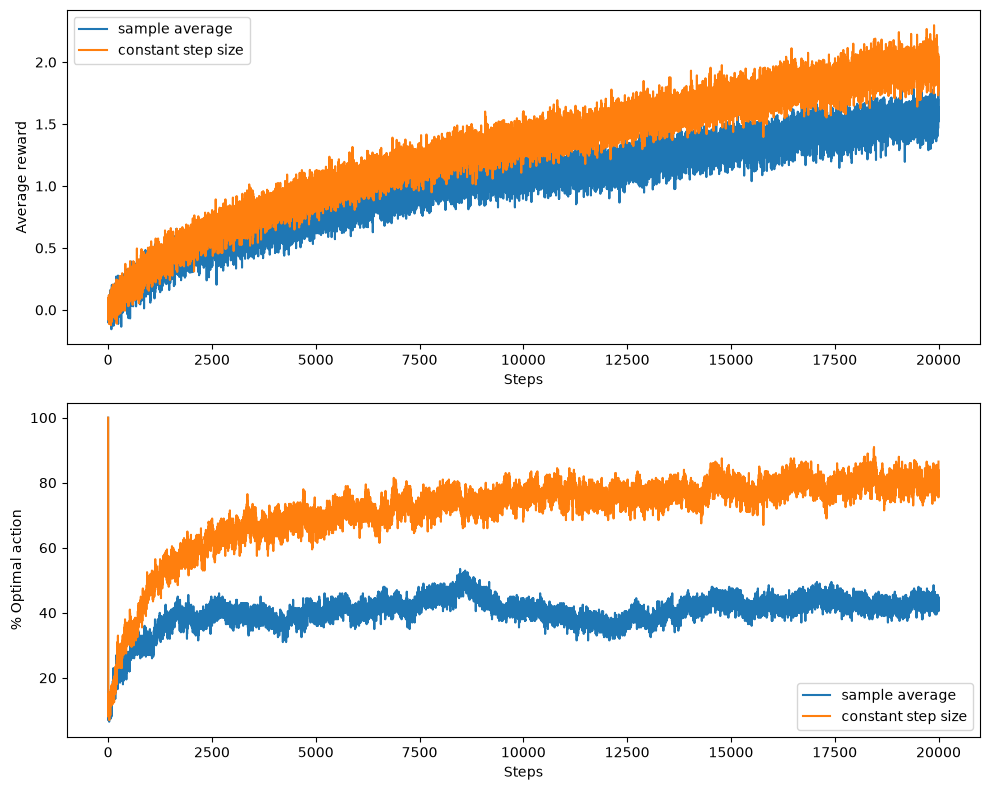

In [ ]:
# Exercise 2.11: non-stationary parameter study
# Create a parameter study between ε-greedy, constant α-greedy, UCB, gradient bandit, and optimistic greedy methods on a non-stationary 10-armed bandit problem.
# Plot average reward using the last 100,000 steps of a 200,000 step run.
# Result:
import numpy as np
import matplotlib.pyplot as plt
import random

def bandit(action, true_rewards):
    reward = random.gauss(true_rewards[action],1)
    return reward

def egreedy(true_rewards, value_estimates, action_chosen, epsilon, steps, rewards, current_step):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = []
            for action, value in enumerate(value_estimates):
                if value == greediest_value:
                    greedy_actions.append(action)
            action = random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
    return reward
            

def agreedy(true_rewards, value_estimates, action_chosen, epsilon, step_size, steps, rewards, current_step):
    for step in range(1, steps + 1):
        if random.random() < epsilon:
            index = random.randint(0,9)
            action = index
        else:
            greediest_value = max(value_estimates)
            greedy_actions = []
            for action, value in enumerate(value_estimates):
                if value == greediest_value:
                    greedy_actions.append(action)
            action = random.choice(greedy_actions)
        reward = bandit(action,true_rewards)
        action_chosen[action] += 1
        value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    return reward
            

def main():
    # initialize parameters in the parameter study
    gradient_alpha = epsilon = confidence = optimistic_initial = 1/128
    # initialize static parameters and numpy arrays
    steps = 200000
    runs = 1
    step_size_alpha = 0.1
    
    (egreedy_parameter_reward,
     agreedy_parameter_reward,
     ucb_parameter_reward,
     optigreedy_parameter_reward,
     gradient_parameter_reward) = [[] for i in range(5)]
    # test range of parameters
    for i in range(10):
        (egreedy_avg_rewards,
         agreedy_avg_rewards,
         ucb_avg_rewards,
         optigreedy_avg_rewards,
         gradient_avg_rewards,) = [np.zeros(steps//2) for i in range(5)] 
        
        # simulate runs
        for run in range(1, runs + 1):
        
            true_rewards  = [0,0,0,0,0,0,0,0,0,0]

            

        
            # e-greedy, constant a-greedy, UCB, optimistic greedy, and gradient initial values
            (gradient_preference,
             egreedy_val_est, egreedy_action_count,
             agreedy_val_est, agreedy_action_count,
             ucb_val_est, ucb_action_count,
             optigreedy_action_count) = [[0] * 10 for i in range(8)]
            optigreedy_val_est = [optimistic_initial] * 10
        
            # make containers for rewards per run
            (egreedy_run_rewards,
             agreedy_run_rewards,
             ucb_run_rewards,
             optigreedy_run_rewards,
             gradient_run_rewards) = [[] for i in range(5)]
        
            # simulate one run for each method
            for step in range(1,steps + 1):
                if epsilon <= 1:
                    ereward = egreedy(true_rewards, egreedy_val_est, egreedy_action_count, epsilon, 1, egreedy_run_rewards, step)
                    if step > 100000:
                        egreedy_run_rewards.append(ereward)
                #agreedy(true_rewards, agreedy_val_est, agreedy_action_count, epsilon, step_size_alpha, 1, agreedy_run_rewards, step)
            
                # true rewards' random walk
                for reward in range(10):
                    true_rewards[reward] += random.gauss(0,.01)
            if epsilon <= 1:
                egreedy_avg_rewards += egreedy_run_rewards
            # agreedy_avg_rewards += agreedy_run_rewards
            # ucb_avg_rewards += egreedy_run_rewards
            # optigreedy_avg_rewards += egreedy_run_rewards
            # gradient_avg_rewards += egreedy_run_rewards
        
        # get average rewards over runs
        egreedy_avg_rewards /= runs
        # agreedy_avg_rewards /= runs
        # ucb_avg_rewards /= runs
        # optigreedy_avg_rewards /= runs
        # gradient_avg_rewards /= runs

        # get average reward of rewards
        egreedy_avg_reward = np.mean(egreedy_avg_rewards)
        # agreedy_avg_reward = np.mean(agreedy_avg_rewards)
        # ucb_avg_reward = np.mean(ucb_avg_rewards)
        # optigreedy_avg_reward = np.mean(optigreedy_avg_rewards)
        # gradient_avg_reward = np.mean(gradient_avg_rewards)
        
        if epsilon <= 1:
            egreedy_parameter_reward.append(egreedy_avg_reward)
        else:
            egreedy_parameter_reward.append(np.nan)
        print(egreedy_avg_reward)
        # agreedy_parameter_reward.append(agreedy_avg_reward)
        # ucb_parameter_reward.append(ucb_avg_reward)
        # optigreedy_parameter_reward.append(optigreedy_avg_reward)
        # gradient_parameter_reward.append(gradient_avg_reward)
        
        # multiply all params by 2
        gradient_alpha, epsilon, confidence, optimistic_initial = [x * 2 for x in (gradient_alpha, epsilon, confidence, optimistic_initial)]


        

    # graphs
    params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4] 
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(params, egreedy_parameter_reward, label='ε-greedy')
    #ax.plot(params, avg_rewards_ucb, label='UCB
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Parameter value')
    ax.set_xticks(params)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'1/{int(1/x)}' if x < 1 else str(int(x))))
    ax.legend()
    plt.show()

main()